<a href="https://colab.research.google.com/github/Dayaanaly/U-Net-vs-SegNet/blob/main/Demo_Unet_vs_SegNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Demo de segmentación con modelo entrenado**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Librerías

In [3]:
!pip install pynrrd

from google.colab import drive
import os
import glob
import cv2
import nrrd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array, load_img

Funciones personalizadas

In [5]:
# ================================
# Funciones personalizadas del modelo
# ================================
# Se definen porque los modelos fueron entrenados con una pérdida
# y métricas personalizadas. Para inferencia se puede usar compile=False,
# pero las dejamos por compatibilidad.

SMOOTH = 1e-6
NUM_CLASSES = 4

def preparar_y_true(y_true):
    y_true = tf.cast(y_true, tf.int32)

    if y_true.shape.rank == 4:
        y_true = tf.squeeze(y_true, axis=-1)

    return y_true


def mean_dice(y_true, y_pred):
    y_true = preparar_y_true(y_true)

    y_true_one_hot = tf.one_hot(y_true, depth=NUM_CLASSES)

    y_pred = tf.cast(y_pred, tf.float32)
    y_true_one_hot = tf.cast(y_true_one_hot, tf.float32)

    axes = [0, 1, 2]

    intersection = tf.reduce_sum(y_true_one_hot * y_pred, axis=axes)
    denominator = tf.reduce_sum(y_true_one_hot + y_pred, axis=axes)

    dice = (2.0 * intersection + SMOOTH) / (denominator + SMOOTH)

    dice_foreground = dice[1:]

    return tf.reduce_mean(dice_foreground)


def mean_iou(y_true, y_pred):
    y_true = preparar_y_true(y_true)

    y_true_one_hot = tf.one_hot(y_true, depth=NUM_CLASSES)

    y_pred = tf.cast(y_pred, tf.float32)
    y_true_one_hot = tf.cast(y_true_one_hot, tf.float32)

    axes = [0, 1, 2]

    intersection = tf.reduce_sum(y_true_one_hot * y_pred, axis=axes)
    union = tf.reduce_sum(y_true_one_hot + y_pred, axis=axes) - intersection

    iou = (intersection + SMOOTH) / (union + SMOOTH)

    iou_foreground = iou[1:]

    return tf.reduce_mean(iou_foreground)


def sparse_ce_dice_loss(y_true, y_pred):
    y_true_prepared = preparar_y_true(y_true)

    ce = tf.keras.losses.sparse_categorical_crossentropy(
        y_true_prepared,
        y_pred
    )

    ce = tf.reduce_mean(ce)

    dice_loss = 1.0 - mean_dice(y_true, y_pred)

    total_loss = ce + dice_loss

    return total_loss


custom_objects_dict = {
    'sparse_ce_dice_loss': sparse_ce_dice_loss,
    'mean_dice': mean_dice,
    'mean_iou': mean_iou
}

Cargar ambos modelos

In [6]:
# ================================
# Cargar modelos entrenados automáticamente
# ================================

output_dir = '/content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Comparativa_Unet_SegNet_80e'

# Buscar modelos guardados de U-Net y SegNet
unet_candidates = glob.glob(os.path.join(output_dir, '*UNet*.keras'))
segnet_candidates = glob.glob(os.path.join(output_dir, '*SegNet*.keras'))

if len(unet_candidates) == 0:
    raise FileNotFoundError("No se encontró ningún modelo U-Net .keras en la carpeta indicada.")

if len(segnet_candidates) == 0:
    raise FileNotFoundError("No se encontró ningún modelo SegNet .keras en la carpeta indicada.")

# Tomar el modelo más reciente de cada arquitectura
unet_model_path = max(unet_candidates, key=os.path.getmtime)
segnet_model_path = max(segnet_candidates, key=os.path.getmtime)

print("Modelo U-Net seleccionado:")
print(unet_model_path)

print("\nModelo SegNet seleccionado:")
print(segnet_model_path)

# Cargar U-Net
model_unet = load_model(
    unet_model_path,
    custom_objects=custom_objects_dict,
    compile=False
)

# Cargar SegNet
model_segnet = load_model(
    segnet_model_path,
    custom_objects=custom_objects_dict,
    compile=False
)

print("\nModelos cargados correctamente.")

Modelo U-Net seleccionado:
/content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Comparativa_Unet_SegNet_80e/UNet_Actual_final_20260526_000706.keras

Modelo SegNet seleccionado:
/content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Comparativa_Unet_SegNet_80e/SegNet_Actual_final_20260526_002429.keras

Modelos cargados correctamente.


Bloque de DEMO

Cantidad de imágenes encontradas: 200
Imagen seleccionada:
/content/drive/MyDrive/Equipo Trifuerza/Datos/Data set grises/Dataset mezclado 2D/Imagen_0.bmp
Forma de la imagen: (320, 224, 1)
Forma de entrada al modelo: (1, 320, 224, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Forma de salida U-Net: (1, 320, 224, 4)
Forma de salida SegNet: (1, 320, 224, 4)
Clases detectadas por U-Net: [0 1 2 3]
Clases detectadas por SegNet: [0 1 2 3]


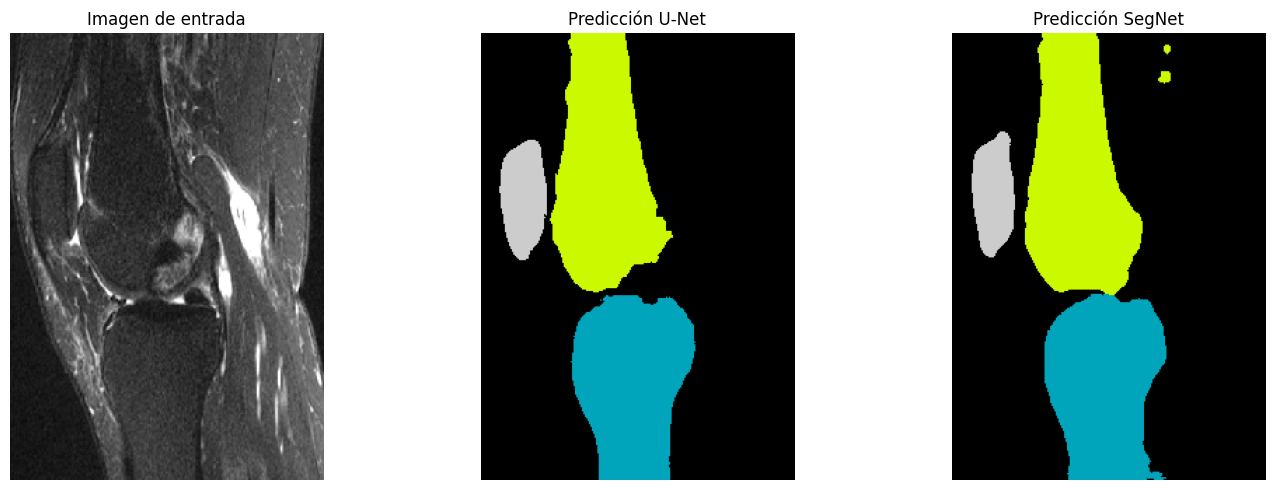

In [10]:
# ================================
# Demo completa de inferencia
# U-Net mejorada vs SegNet
# ================================

# Parámetros usados durante el entrenamiento
IMG_HEIGHT = 320
IMG_WIDTH = 224
NUM_CLASSES = 4

# Carpeta de imágenes
image_dir = '/content/drive/MyDrive/Equipo Trifuerza/Datos/Data set grises/Dataset mezclado 2D'

# Extensiones válidas
valid_extensions = ('.nrrd', '.bmp')

# ================================
# Función para cargar imagen de prueba
# ================================
def load_image_custom(filepath, target_size=(IMG_HEIGHT, IMG_WIDTH), color_mode='grayscale'):
    ext = os.path.splitext(filepath)[1].lower()

    if ext == '.nrrd':
        img_data, header = nrrd.read(filepath)

        if color_mode == 'grayscale':
            # Si tiene varios canales, convertir a escala de grises
            if img_data.ndim == 3 and img_data.shape[-1] > 1:
                img_data = np.mean(img_data, axis=-1)

            # Si tiene canal extra, quitarlo temporalmente
            if img_data.ndim == 3 and img_data.shape[-1] == 1:
                img_data = np.squeeze(img_data, axis=-1)

            # Redimensionar al tamaño usado en entrenamiento
            img_resized = cv2.resize(
                img_data,
                (target_size[1], target_size[0])
            )

            # Agregar canal: (320, 224, 1)
            img_resized = np.expand_dims(img_resized, axis=-1)

            return img_resized

        else:
            raise ValueError("Para este demo se espera imagen en escala de grises.")

    else:
        return img_to_array(
            load_img(filepath, target_size=target_size, color_mode=color_mode)
        )


# ================================
# Seleccionar imagen para demo
# ================================
image_files = sorted([
    f for f in os.listdir(image_dir)
    if f.lower().endswith(valid_extensions)
])

print("Cantidad de imágenes encontradas:", len(image_files))

# Cambia este índice para probar otra imagen
idx = 0

image_path = os.path.join(image_dir, image_files[idx])

print("Imagen seleccionada:")
print(image_path)


# ================================
# Cargar y preparar imagen
# ================================
demo_image = load_image_custom(
    image_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    color_mode='grayscale'
)

# Normalizar igual que en entrenamiento
demo_image = demo_image.astype('float32') / 255.0

# Agregar dimensión batch: (1, 320, 224, 1)
demo_image_batch = np.expand_dims(demo_image, axis=0)

print("Forma de la imagen:", demo_image.shape)
print("Forma de entrada al modelo:", demo_image_batch.shape)


# ================================
# Inferencia con U-Net y SegNet
# ================================

# Predicción con U-Net
pred_unet = model_unet.predict(demo_image_batch)
pred_unet_class = np.argmax(pred_unet, axis=-1)[0]

# Predicción con SegNet
pred_segnet = model_segnet.predict(demo_image_batch)
pred_segnet_class = np.argmax(pred_segnet, axis=-1)[0]

print("Forma de salida U-Net:", pred_unet.shape)
print("Forma de salida SegNet:", pred_segnet.shape)

print("Clases detectadas por U-Net:", np.unique(pred_unet_class))
print("Clases detectadas por SegNet:", np.unique(pred_segnet_class))


# ================================
# Visualización de inferencia
# ================================
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(demo_image.squeeze(), cmap='gray')
plt.title('Imagen de entrada')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(
    pred_unet_class,
    cmap='nipy_spectral',
    vmin=0,
    vmax=NUM_CLASSES - 1
)
plt.title('Predicción U-Net')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(
    pred_segnet_class,
    cmap='nipy_spectral',
    vmin=0,
    vmax=NUM_CLASSES - 1
)
plt.title('Predicción SegNet')
plt.axis('off')

plt.tight_layout()
plt.show()